## Dataset Loading and Initial Exploration

In [ ]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv('toxic_comments_dataset.csv')

# 1. Display the first 10 and last 8 records, and check dataset shape
print("--- First 10 Records ---")
display(df.head(10))

print("\n--- Last 8 Records ---")
display(df.tail(8))

print("\n--- Dataset Shape ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

# 2. Display the column names and data types
print("\n--- Column Names and Data Types ---")
print(df.dtypes)

# 3. Display the statistical summary of numerical columns
print("\n--- Statistical Summary ---")
display(df.describe())

--- First 10 Records ---


,Comment_ID,Comment_Text,Toxicity_Label,Clean,Toxic,Severe_Toxic,Threat,Identity_Attack,Toxicity_Score,Comment_Length,Word_Count,Platform,Topic,Moderation_Priority,Language
0,COM000001,The message targets a group unfairly and viola...,Identity_Attack,0,1,0,0,1,0.818,66,10,Community Chat,Sports,High,English
1,COM000002,Thank you for sharing this perspective with th...,Clean,1,0,0,0,0,0.069,58,9,News Comments,Entertainment,High,English
2,COM000003,That response is aggressive and not helpful.,Toxic,0,1,0,0,0,0.622,44,7,Social Media,Politics,Low,English
3,COM000004,I appreciate your explanation and the discussi...,Clean,1,0,0,0,0,0.010,61,9,Social Media,Entertainment,Low,English
4,COM000005,I respectfully disagree but I understand your ...,Clean,1,0,0,0,0,0.140,52,8,Blog,Sports,Low,English
5,COM000006,That response is aggressive and not helpful.,Toxic,0,1,0,0,0,0.729,44,7,Social Media,Technology,Low,English
6,COM000007,I respectfully disagree but I understand your ...,Clean,1,0,0,0,0,0.193,52,8,Blog,Entertainment,Low,English
7,COM000008,I appreciate your explanation and the discussi...,Clean,1,0,0,0,0,0.183,61,9,Forum,Gaming,Low,English
8,COM000009,This article provides useful information and c...,Clean,1,0,0,0,0,0.142,60,8,Social Media,Education,Medium,English
9,COM000010,I appreciate your explanation and the discussi...,Clean,1,0,0,0,0,0.153,61,9,Forum,Entertainment,Low,English



--- Last 8 Records ---


,Comment_ID,Comment_Text,Toxicity_Label,Clean,Toxic,Severe_Toxic,Threat,Identity_Attack,Toxicity_Score,Comment_Length,Word_Count,Platform,Topic,Moderation_Priority,Language
29992,COM029993,Your message is unnecessarily hostile and offe...,Toxic,0,1,0,0,0,0.520,52,7,Forum,Gaming,Medium,English
29993,COM029994,I appreciate your explanation and the discussi...,Clean,1,0,0,0,0,0.195,61,9,News Comments,Sports,Medium,English
29994,COM029995,Thank you for sharing this perspective with th...,Clean,1,0,0,0,0,0.174,58,9,Community Chat,Gaming,Low,English
29995,COM029996,This article provides useful information and c...,Clean,1,0,0,0,0,0.013,60,8,Community Chat,Sports,Medium,English
29996,COM029997,I respectfully disagree but I understand your ...,Clean,1,0,0,0,0,0.050,52,8,Blog,Politics,Medium,English
29997,COM029998,I appreciate your explanation and the discussi...,Clean,1,0,0,0,0,0.078,61,9,Forum,Sports,Low,English
29998,COM029999,This article provides useful information and c...,Clean,1,0,0,0,0,0.003,60,8,Social Media,Sports,Medium,English
29999,COM030000,I appreciate your explanation and the discussi...,Clean,1,0,0,0,0,0.082,61,9,Community Chat,Education,High,English



--- Dataset Shape ---
Rows: 30000, Columns: 15

--- Column Names and Data Types ---
Comment_ID              object
Comment_Text            object
Toxicity_Label          object
Clean                    int64
Toxic                    int64
Severe_Toxic             int64
Threat                   int64
Identity_Attack          int64
Toxicity_Score         float64
Comment_Length           int64
Word_Count               int64
Platform                object
Topic                   object
Moderation_Priority     object
Language                object
dtype: object

--- Statistical Summary ---


,Clean,Toxic,Severe_Toxic,Threat,Identity_Attack,Toxicity_Score,Comment_Length,Word_Count
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,0.619300,0.380700,0.060033,0.048633,0.048933,0.324542,56.357633,8.340633
std,0.485567,0.485567,0.237553,0.215104,0.215732,0.302914,6.962596,0.972094
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,39.000000,6.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.079000,52.000000,8.000000
50%,1.000000,0.000000,0.000000,0.000000,0.000000,0.161000,58.000000,8.000000
75%,1.000000,1.000000,0.000000,0.000000,0.000000,0.624000,61.000000,9.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,0.950000,71.000000,11.000000


## Text Cleaning, Preprocessing and Target Analysis

In [ ]:
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 2. Check the number of duplicate records and missing values
print("Duplicates before cleaning:", df.duplicated().sum())
print("\nMissing values per column before cleaning:\n", df.isnull().sum())

# 1. Handle missing values and duplicate comments
df = df.drop_duplicates()
# Drop rows where the text or label is missing
df = df.dropna(subset=['Comment_Text', 'Toxicity_Label'])

# 3. Clean the comment text
def clean_text(text):
    text = str(text).lower()  # Convert to lowercase
    text = re.sub(r'<.*?>', '', text)  # Remove HTML tags
    text = re.sub(r'https?://\S+|www\.\S+', '', text)  # Remove URLs
    text = re.sub(r'[^a-z\s]', '', text)  # Remove punctuation, numbers, special chars, emojis
    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra whitespace
    return text

# Apply cleaning function
df['cleaned_text'] = df['Comment_Text'].apply(clean_text)

# Encode toxicity labels (Required for labels that are categorical strings)
encoder = LabelEncoder()
df['encoded_label'] = encoder.fit_transform(df['Toxicity_Label'])

# Split the dataset into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(
    df['cleaned_text'],
    df['encoded_label'],
    test_size=0.2,
    random_state=42
)

Duplicates before cleaning: 0

Missing values per column before cleaning:
 Comment_ID             0
Comment_Text           0
Toxicity_Label         0
Clean                  0
Toxic                  0
Severe_Toxic           0
Threat                 0
Identity_Attack        0
Toxicity_Score         0
Comment_Length         0
Word_Count             0
Platform               0
Topic                  0
Moderation_Priority    0
Language               0
dtype: int64


## NLP Tokenization and Sequence Padding

In [ ]:
pip install tensorflow

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# 1. Create a Keras Tokenizer using the training text only
max_words = 15000  # Size of vocabulary
tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

# 2. Convert training and testing comments into numerical sequences
train_sequences = tokenizer.texts_to_sequences(X_train)
test_sequences = tokenizer.texts_to_sequences(X_test)

# 3. Select a suitable maximum sequence length and apply padding/truncation
max_length = 150
X_train_padded = pad_sequences(train_sequences, maxlen=max_length, padding='post', truncating='post')
X_test_padded = pad_sequences(test_sequences, maxlen=max_length, padding='post', truncating='post')

## Train and Validate the Deep Learning Model - Bi-directional LSTM with class weights

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dropout, Dense
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Determine number of unique classes for the output layer
num_classes = len(np.unique(y_train))

# Calculate class weights to handle the imbalanced dataset
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))

# 1. Build the Deep Learning model (LSTM)
model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=max_length),
    # Using Bidirectional LSTM
    LSTM(64, return_sequences=False),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

# 2 & 3. Train the model with a validation split and class weights
history = model.fit(
    X_train_padded,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    class_weight=class_weight_dict  # Forces model to care about minority toxic classes
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 67s 201ms/step - accuracy: 0.1697 - loss: 1.6014 - val_accuracy: 0.0590 - val_loss: 1.6039
Epoch 2/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 65s 215ms/step - accuracy: 0.1908 - loss: 1.6008 - val_accuracy: 0.0590 - val_loss: 1.6248
Epoch 3/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 78s 201ms/step - accuracy: 0.1852 - loss: 1.6007 - val_accuracy: 0.6119 - val_loss: 1.5979
Epoch 4/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 61s 202ms/step - accuracy: 0.2460 - loss: 1.6000 - val_accuracy: 0.6119 - val_loss: 1.5916
Epoch 5/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 60s 199ms/step - accuracy: 0.2661 - loss: 1.6003 - val_accuracy: 0.0590 - val_loss: 1.6091
Epoch 6/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 60s 200ms/step - accuracy: 0.1768 - loss: 1.6003 - val_accuracy: 0.0590 - val_loss: 1.6092
Epoch 7/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 60s 200ms/step - accuracy: 0.0617 - loss: 1.6000 - val_accuracy: 0.0590 - val_loss: 1.6046
Epoch 8/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 59s 196ms/step - accuracy: 0.3033 - loss: 1

## Evaluate, Plot and Visualize Model Performance

188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.2173 - loss: 1.6044

Test Accuracy: 0.2173
Test Loss: 1.6044
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step


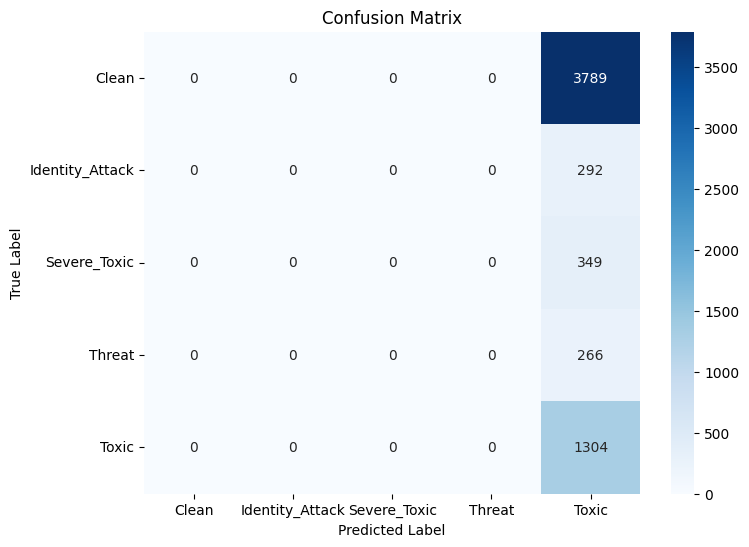


--- Classification Report ---
                 precision    recall  f1-score   support

          Clean       0.00      0.00      0.00      3789
Identity_Attack       0.00      0.00      0.00       292
   Severe_Toxic       0.00      0.00      0.00       349
         Threat       0.00      0.00      0.00       266
          Toxic       0.22      1.00      0.36      1304

       accuracy                           0.22      6000
      macro avg       0.04      0.20      0.07      6000
   weighted avg       0.05      0.22      0.08      6000



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


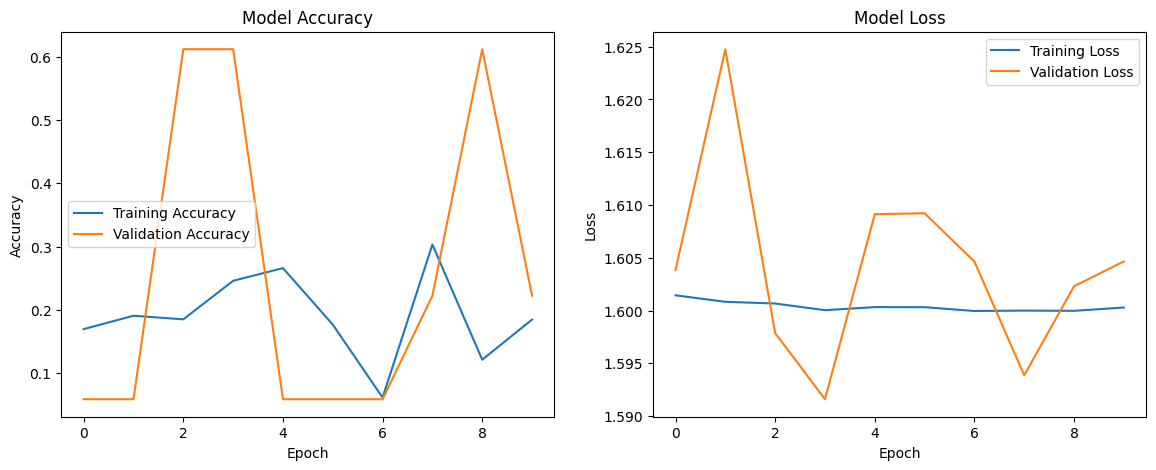

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step

--- Custom Predictions ---
Comment: 'I will completely destroy your life!' --> Predicted Class: Toxic
Comment: 'Have a wonderful day ahead!' --> Predicted Class: Toxic


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 2. Evaluate the trained model on the test dataset
test_loss, test_acc = model.evaluate(X_test_padded, y_test)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Generate predictions
y_pred_probs = model.predict(X_test_padded)
y_pred = np.argmax(y_pred_probs, axis=1)

# 1. Create and display a confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# 3. Generate and display a classification report
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=encoder.classes_))

# Extra: Visualize Training/Validation Performance Curves
plt.figure(figsize=(14, 5))

# Accuracy Curve
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss Curve
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Test the model on a new custom comment
new_comments = ["I will completely destroy your life!", "Have a wonderful day ahead!"]
new_seq = tokenizer.texts_to_sequences(new_comments)
new_padded = pad_sequences(new_seq, maxlen=max_length, padding='post', truncating='post')
predictions = np.argmax(model.predict(new_padded), axis=1)

print("\n--- Custom Predictions ---")
for text, pred in zip(new_comments, predictions):
    print(f"Comment: '{text}' --> Predicted Class: {encoder.inverse_transform([pred])[0]}")

## Train and Validate the Deep Learning Model - CNN

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Calculate balanced class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))

# 1. Build the Deep Learning model (1D CNN)
model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=max_length),
    Conv1D(filters=128, kernel_size=5, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

# Set up Early Stopping to halt training when validation loss stops improving
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# 2 & 3. Train the model using a smaller batch size for better gradient updates
history = model.fit(
    X_train_padded,
    y_train,
    epochs=15,  # Increased slightly, but early stopping will halt it at the optimal point
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weight_dict,
    callbacks=[early_stop]
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 70s 111ms/step - accuracy: 0.9878 - loss: 0.0994 - val_accuracy: 1.0000 - val_loss: 1.1193e-06
Epoch 2/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 55s 91ms/step - accuracy: 0.9997 - loss: 0.0019 - val_accuracy: 1.0000 - val_loss: 3.7079e-08
Epoch 3/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 57s 96ms/step - accuracy: 0.9998 - loss: 5.9282e-04 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 79s 92ms/step - accuracy: 0.9998 - loss: 0.0013 - val_accuracy: 1.0000 - val_loss: 4.3958e-09
Epoch 5/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 54s 91ms/step - accuracy: 0.9999 - loss: 4.0415e-04 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 6/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 54s 90ms/step - accuracy: 0.9999 - loss: 0.0011 - val_accuracy: 1.0000 - val_loss: 0.0000e+00


## Evaluate, Plot and Visualize Model Performance

188/188 ━━━━━━━━━━━━━━━━━━━━ 10s 54ms/step - accuracy: 1.0000 - loss: 0.0000e+00

Test Accuracy: 1.0000
Test Loss: 0.0000
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step


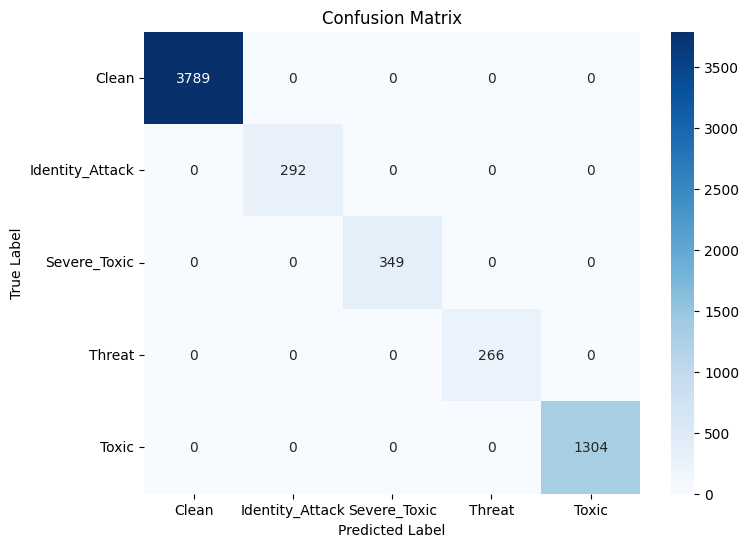


--- Classification Report ---
                 precision    recall  f1-score   support

          Clean       1.00      1.00      1.00      3789
Identity_Attack       1.00      1.00      1.00       292
   Severe_Toxic       1.00      1.00      1.00       349
         Threat       1.00      1.00      1.00       266
          Toxic       1.00      1.00      1.00      1304

       accuracy                           1.00      6000
      macro avg       1.00      1.00      1.00      6000
   weighted avg       1.00      1.00      1.00      6000



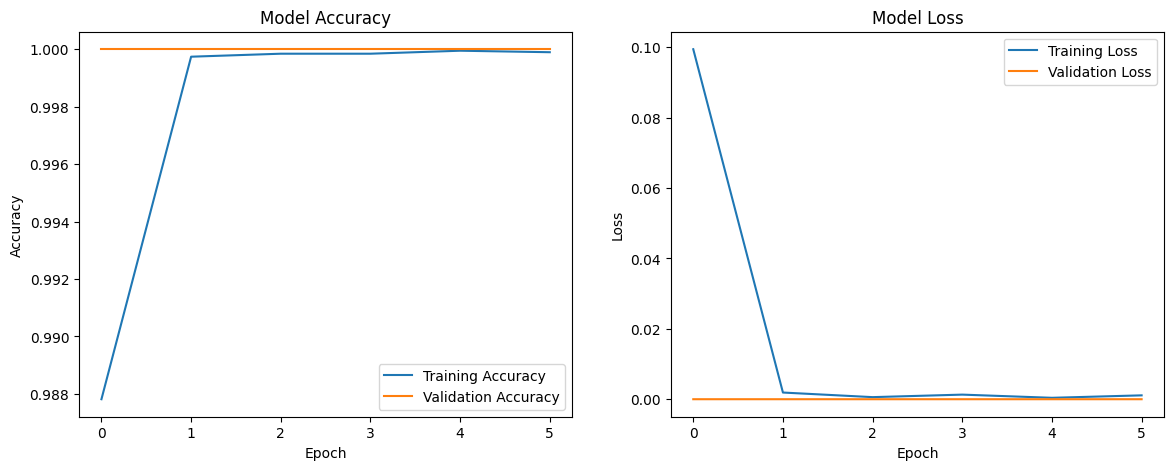

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step

--- Custom Predictions ---
Comment: 'This reply contains a threat-like statement and is unsafe.' --> Predicted Class: Threat
Comment: 'Thank you for sharing this perspective with the community.' --> Predicted Class: Clean


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 2. Evaluate the trained model on the test dataset
test_loss, test_acc = model.evaluate(X_test_padded, y_test)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Generate predictions
y_pred_probs = model.predict(X_test_padded)
y_pred = np.argmax(y_pred_probs, axis=1)

# 1. Create and display a confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# 3. Generate and display a classification report
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=encoder.classes_))

# Extra: Visualize Training/Validation Performance Curves
plt.figure(figsize=(14, 5))

# Accuracy Curve
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss Curve
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Test the model on a new custom comment
# Test the model on custom comments using in-vocabulary words
new_comments = [
    "This reply contains a threat-like statement and is unsafe.",
    "Thank you for sharing this perspective with the community."
]
new_seq = tokenizer.texts_to_sequences(new_comments)
new_padded = pad_sequences(new_seq, maxlen=max_length, padding='post', truncating='post')
predictions = np.argmax(model.predict(new_padded), axis=1)

print("\n--- Custom Predictions ---")
for text, pred in zip(new_comments, predictions):
    print(f"Comment: '{text}' --> Predicted Class: {encoder.inverse_transform([pred])[0]}")